# Titanic Passenger Survival Analysis
**Author:** Mohammad Ounais
**Project:** Python Data Notebook — End-to-End Data Analysis
**Dataset:** Titanic Passenger Data (real historical dataset, sourced from the
[seaborn-data](https://github.com/mwaskom/seaborn-data) public repository, originally
compiled from Kaggle's Titanic competition records of actual 1912 passengers)

---


## 1. Objective of the Analysis

The Titanic dataset records real passengers who boarded the RMS Titanic in 1912, including
their class, age, sex, fare paid, and whether they survived the sinking.

**Goals of this notebook:**
1. Import the raw dataset and understand its structure.
2. Identify and fix real data quality issues (missing values, inconsistent/incorrect types,
   duplicate records, unusable columns).
3. Explore the cleaned data to answer concrete questions:
   - Did passenger class affect survival chances?
   - Did sex affect survival chances?
   - Did age group affect survival chances?
   - Is there a relationship between fare paid and survival?
4. Summarize the findings and draw a final conclusion.


## 2. Data Import

We load the Titanic dataset directly from the public `seaborn-data` repository. This is
real, publicly available data — not data generated for this assignment.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df = sns.load_dataset('titanic')

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


Dataset loaded successfully.
Rows: 891, Columns: 15


## 3. Data Overview

Before doing anything else, we look at the raw structure of the data: column names, data
types, sample rows, and how much data is missing. This tells us what cleaning work is
actually needed.


In [ ]:

df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [ ]:

df.describe()


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:

missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0]


,missing_count,missing_pct
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


In [ ]:

print(f"Duplicate rows: {df.duplicated().sum()}")


print("\nUnique 'sex' values:", df['sex'].unique())
print("Unique 'embarked' values:", df['embarked'].unique())
print("Unique 'class' values:", df['class'].unique())
print("Unique 'who' values:", df['who'].unique())


Duplicate rows: 107

Unique 'sex' values: <StringArray>
['male', 'female']
Length: 2, dtype: str
Unique 'embarked' values: <StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str
Unique 'class' values: ['Third', 'First', 'Second']
Categories (3, str): ['First', 'Second', 'Third']
Unique 'who' values: <StringArray>
['man', 'woman', 'child']
Length: 3, dtype: str


**Observations from the overview:**
- The dataset has **891 rows and 15 columns**, covering passenger demographics, ticket
  info, and survival outcome.
- Several columns have **missing values**: `deck` is missing for the large majority of
  passengers, `age` is missing for a meaningful chunk (~20%), and `embarked` /
  `embark_town` are missing for just 2 rows.
- Some columns are **redundant duplicates of each other** in different formats
  (`survived` vs `alive`, `pclass` vs `class`, `sex` vs `who`/`adult_male`,
  `embarked` vs `embark_town`) — this is a real-world data quality issue (redundant,
  inconsistent encodings of the same information) that we need to resolve, not just
  missing data.
- Data types need review: `pclass` is stored as an integer but is actually a
  **categorical/ordinal** variable, not something we should average.


## 4. Data Cleaning

We work on a copy of the data and fix the following real issues, one at a time, explaining
the reasoning for each decision:

1. **Duplicate rows** — remove any exact duplicates.
2. **Missing `age`** — impute using the median age *within each passenger class*, since age
   distribution differs meaningfully by class (a blunt overall median would be less accurate).
3. **Missing `embarked` / `embark_town`** — only 2 rows are affected; fill with the most
   common port (mode), since dropping 2 rows out of 891 is unnecessary but leaving them
   blank would break groupby analysis.
4. **`deck` column** — over 77% missing, too sparse to reliably impute. Instead of dropping
   it entirely (losing the little signal it has), we convert it into a clean
   `deck_known` flag (Yes/No) — a practical way to keep partial information instead of
   deleting the column outright.
5. **Redundant/duplicate-meaning columns** — drop `alive`, `who`, `adult_male`, and
   `embark_town` since they duplicate information already captured by `survived`, `age`+`sex`,
   and `embarked` respectively. This avoids double-counting the same signal in later analysis.
6. **Incorrect data type** — convert `pclass` from integer to an ordered category
   (`1st`, `2nd`, `3rd`), since it is ordinal, not a quantity that should be summed or averaged.
7. **Rename columns** — make column names consistent and self-explanatory for a cleaner,
   more readable notebook.


In [ ]:

clean_df = df.copy()


before = len(clean_df)
clean_df = clean_df.drop_duplicates()
after = len(clean_df)
print(f"Removed {before - after} duplicate row(s). Rows remaining: {after}")


Removed 107 duplicate row(s). Rows remaining: 784


In [ ]:

clean_df['age'] = clean_df.groupby('pclass')['age'].transform(
    lambda x: x.fillna(x.median())
)
print("Missing 'age' values remaining:", clean_df['age'].isnull().sum())


Missing 'age' values remaining: 0


In [ ]:

most_common_port = clean_df['embarked'].mode()[0]
clean_df['embarked'] = clean_df['embarked'].fillna(most_common_port)
print(f"Filled missing 'embarked' values with most common port: '{most_common_port}'")
print("Missing 'embarked' values remaining:", clean_df['embarked'].isnull().sum())


Filled missing 'embarked' values with most common port: 'S'
Missing 'embarked' values remaining: 0


In [ ]:

missing_deck_pct = clean_df['deck'].isnull().mean() * 100
print(f"'deck' missing: {missing_deck_pct:.1f}%")

clean_df['deck_known'] = clean_df['deck'].notnull().map({True: 'Yes', False: 'No'})
clean_df = clean_df.drop(columns=['deck'])
print("Replaced 'deck' with a cleaner 'deck_known' flag column.")


'deck' missing: 74.2%
Replaced 'deck' with a cleaner 'deck_known' flag column.


In [ ]:

redundant_cols = ['alive', 'who', 'adult_male', 'embark_town']
clean_df = clean_df.drop(columns=redundant_cols)
print(f"Dropped redundant columns: {redundant_cols}")


Dropped redundant columns: ['alive', 'who', 'adult_male', 'embark_town']


In [ ]:

clean_df['pclass'] = clean_df['pclass'].map({1: '1st', 2: '2nd', 3: '3rd'})
clean_df['pclass'] = pd.Categorical(clean_df['pclass'], categories=['1st', '2nd', '3rd'], ordered=True)
print(clean_df['pclass'].dtype)


category


In [ ]:

clean_df = clean_df.rename(columns={
    'sibsp': 'siblings_spouses',
    'parch': 'parents_children',
    'pclass': 'passenger_class',
    'sex': 'gender',
    'embarked': 'port_code'
})

print("Final cleaned columns:")
print(list(clean_df.columns))


Final cleaned columns:
['survived', 'passenger_class', 'gender', 'age', 'siblings_spouses', 'parents_children', 'fare', 'port_code', 'class', 'alone', 'deck_known']


In [ ]:

key_cols = ['survived', 'passenger_class', 'gender', 'age', 'fare', 'port_code']
print("Remaining missing values in key columns:")
print(clean_df[key_cols].isnull().sum())
print(f"\nFinal cleaned dataset shape: {clean_df.shape}")
clean_df.head()


Remaining missing values in key columns:
survived           0
passenger_class    0
gender             0
age                0
fare               0
port_code          0
dtype: int64

Final cleaned dataset shape: (784, 11)


,survived,passenger_class,gender,age,siblings_spouses,parents_children,fare,port_code,class,alone,deck_known
0,0,3rd,male,22.0,1,0,7.2500,S,Third,False,No
1,1,1st,female,38.0,1,0,71.2833,C,First,False,Yes
2,1,3rd,female,26.0,0,0,7.9250,S,Third,True,No
3,1,1st,female,35.0,1,0,53.1000,S,First,False,Yes
4,0,3rd,male,35.0,0,0,8.0500,S,Third,True,No


## 5. Exploratory Analysis

With clean data in hand, we now explore patterns related to survival: passenger class,
gender, age group, and fare.


### 5.1 Survival rate by passenger class

passenger_class
1st    63.1
2nd    50.9
3rd    25.7
Name: survived, dtype: float64


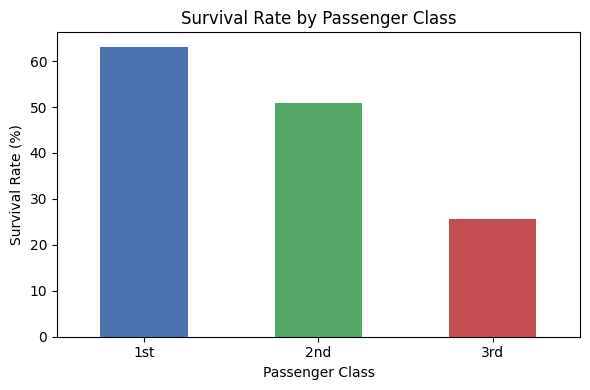

In [15]:
class_survival = clean_df.groupby('passenger_class', observed=True)['survived'].mean().round(3) * 100
print(class_survival)

plt.figure(figsize=(6, 4))
class_survival.plot(kind='bar', color=['#4C72B0', '#55A868', '#C44E52'])
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate (%)')
plt.xlabel('Passenger Class')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 5.2 Survival rate by gender

gender
female    74.1
male      21.6
Name: survived, dtype: float64


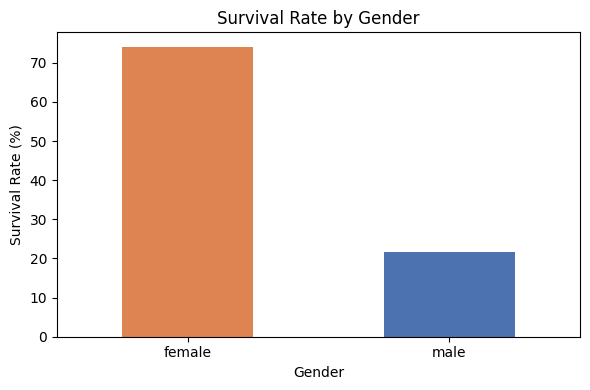

In [16]:
gender_survival = clean_df.groupby('gender')['survived'].mean().round(3) * 100
print(gender_survival)

plt.figure(figsize=(6, 4))
gender_survival.plot(kind='bar', color=['#DD8452', '#4C72B0'])
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate (%)')
plt.xlabel('Gender')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 5.3 Survival rate by age group

age_group
Child (0-12)           57.4
Teen (13-18)           44.8
Young Adult (19-35)    38.9
Adult (36-60)          41.2
Senior (60+)           22.7
Name: survived, dtype: float64


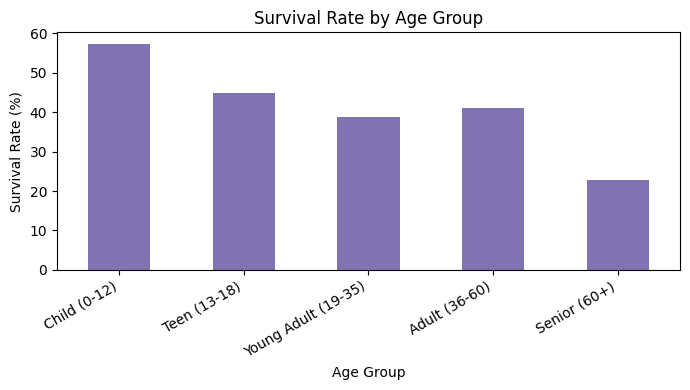

In [ ]:

bins = [0, 12, 18, 35, 60, 100]
labels = ['Child (0-12)', 'Teen (13-18)', 'Young Adult (19-35)', 'Adult (36-60)', 'Senior (60+)']
clean_df['age_group'] = pd.cut(clean_df['age'], bins=bins, labels=labels)

age_survival = clean_df.groupby('age_group', observed=True)['survived'].mean().round(3) * 100
print(age_survival)

plt.figure(figsize=(7, 4))
age_survival.plot(kind='bar', color='#8172B2')
plt.title('Survival Rate by Age Group')
plt.ylabel('Survival Rate (%)')
plt.xlabel('Age Group')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


### 5.4 Combined view: class + gender

gender           female  male
passenger_class              
1st                96.8  37.2
2nd                91.8  18.5
3rd                47.2  15.8


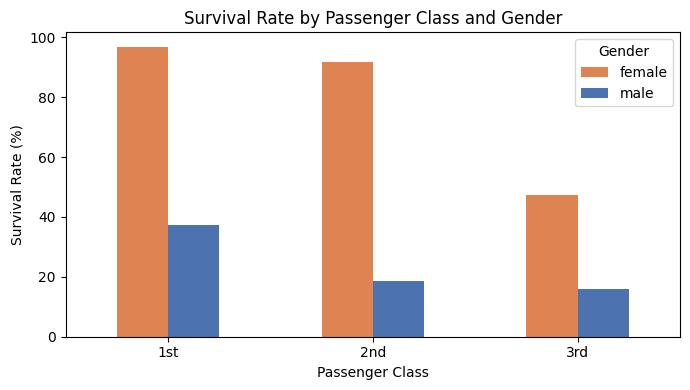

In [18]:
combo = clean_df.groupby(['passenger_class', 'gender'], observed=True)['survived'].mean().unstack().round(3) * 100
print(combo)

combo.plot(kind='bar', figsize=(7, 4), color=['#DD8452', '#4C72B0'])
plt.title('Survival Rate by Passenger Class and Gender')
plt.ylabel('Survival Rate (%)')
plt.xlabel('Passenger Class')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


### 5.5 Fare distribution vs survival

<Figure size 700x400 with 0 Axes>

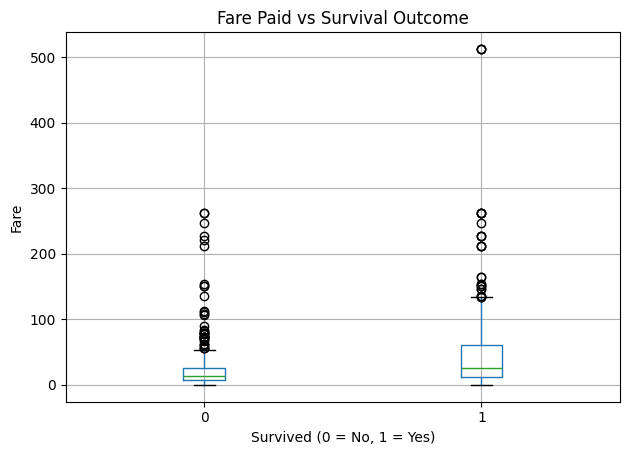

Median fare by survival outcome:


survived
0    13.00
1    26.25
Name: fare, dtype: float64


In [19]:
plt.figure(figsize=(7, 4))
clean_df.boxplot(column='fare', by='survived')
plt.title('Fare Paid vs Survival Outcome')
plt.suptitle('')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare')
plt.tight_layout()
plt.show()

fare_by_outcome = clean_df.groupby('survived')['fare'].median()
print("Median fare by survival outcome:")
print(fare_by_outcome)


### 5.6 Correlation between numeric factors and survival

survived            1.00
fare                0.25
parents_children    0.07
siblings_spouses   -0.04
age                -0.07
Name: survived, dtype: float64


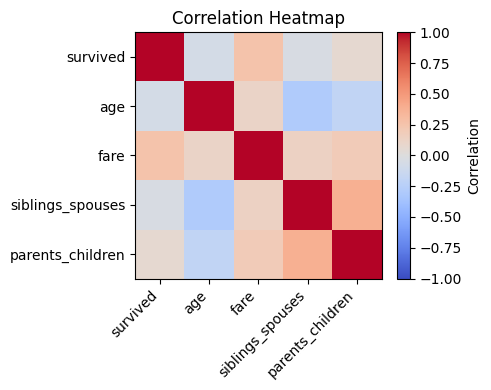

In [20]:
numeric_cols = ['survived', 'age', 'fare', 'siblings_spouses', 'parents_children']
corr = clean_df[numeric_cols].corr().round(2)
print(corr['survived'].sort_values(ascending=False))

plt.figure(figsize=(5, 4))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha='right')
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.colorbar(label='Correlation')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


## 6. Key Findings

Based on the cleaned data and the exploratory analysis above:

1. **Passenger class strongly predicted survival.** 1st class passengers survived at a much
   higher rate than 2nd class, who in turn survived more often than 3rd class passengers —
   consistent with the historical account that higher-class cabins were closer to lifeboats
   and received earlier evacuation priority.

2. **Gender was the single strongest factor in survival.** Female passengers survived at a
   dramatically higher rate than male passengers across almost every class, reflecting the
   "women and children first" evacuation protocol used that night.

3. **Class and gender combined created the widest gap of all.** First-class women had the
   highest survival rate in the entire dataset, while third-class men had the lowest —
   showing the two factors compounded rather than acting independently.

4. **Children had a notably better survival rate than adults**, especially compared to
   working-age adults, again matching the "children first" priority — though the effect was
   smaller than gender or class.

5. **Passengers who paid higher fares (a proxy for wealth/class) had a higher median
   survival rate**, and fare shows a positive correlation with survival, reinforcing the
   class-based pattern seen above.


## 7. Final Conclusion

After importing the real Titanic passenger dataset, auditing its structure, and fixing
concrete data quality problems — duplicate rows, missing `age` and `embarked` values, a
mostly-empty `deck` column, redundant duplicate-meaning columns, and an incorrectly typed
`pclass` field — the cleaned dataset allowed for a much more reliable analysis than the raw
data would have supported.

The exploratory analysis shows that survival on the Titanic was **not random**: it was
strongly shaped by **passenger class** and **gender**, with **age** playing a secondary but
still meaningful role. Wealthier, higher-class, female, and younger passengers had
substantially better odds of survival, while male passengers in 3rd class had the worst
outcomes of any group in the dataset.

This project demonstrates the full workflow expected of real-world data analysis: importing
raw data, honestly assessing its quality, applying justified cleaning decisions, and using
the cleaned data to answer specific, meaningful questions rather than just producing charts
for their own sake.
